[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/mhuertascompany/euclid-school-2026/blob/main/Y1/notebooks/3-euclidzoo_cnn_vit.ipynb)

# Galaxy zoo image classification - basics with PyTorch
## Ecole Rodolphe Cledassou 2026

> Marc Huertas-Company & Hubert Bretonnière 

This notebook illustrates how to train a simple ViT from scratch to estimate the morphologies of galaxies observed with the Euclid Space Telescope. The training set is composed of galaxy stamps labeled by visual inspection through citizen science

## Loading and exploring the datasets


Unzip it locally and update the `PATH_TO_DATADIR` according to your system.  
Otherwise use the second method to load directly from the URL.

In [1]:
import torch
import numpy as np
import os, shutil, glob

from datasets import load_dataset,disable_caching

PATH_TO_DATADIR = "zoo-data"

import os, shutil, glob
from datasets import load_dataset

# 1) Remove global caches of imagefolder
hf_home = os.path.expanduser("~/.cache/huggingface/datasets")
for p in glob.glob(os.path.join(hf_home, "imagefolder", "default-*")):
    print("Removing global cache:", p)
    shutil.rmtree(p, ignore_errors=True)

# 2) Remove your project-local cache as well
local_cache = os.path.abspath("./.hf_cache")
print("Removing local cache:", local_cache)
shutil.rmtree(local_cache, ignore_errors=True)
os.makedirs(local_cache, exist_ok=True)

# 3) Rebuild clean
ds = load_dataset(
    "imagefolder",
    data_files={
        "train": ["zoo-data/train/*/*"],
        "test":  ["zoo-data/test/*/*"],
    },
    drop_labels=False,
    keep_in_memory=False,
    cache_dir=local_cache,
    download_mode="force_redownload",   # force a full rebuild
)
train_set, test_set = ds["train"], ds["test"]
print(train_set, test_set)

class_names = train_set.features["label"].names
# Attach a .classes attribute to both splits
for split in ("train", "test"):
    setattr(ds[split], "classes", class_names)


print(train_set.classes)
print(test_set.classes)

globals()["train_dataset_plot"] = train_set

/opt/homebrew/Caskroom/miniconda/base/envs/euclid-school/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Removing local cache: /Users/hubertbretonniere/work/astrophysics/ede_2026/euclid-school-2026/Y1/notebooks/.hf_cache


Generating train split: 2760 examples [00:00, 29692.06 examples/s]
Generating test split: 691 examples [00:00, 45886.20 examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 2760
}) Dataset({
    features: ['image', 'label'],
    num_rows: 691
})
['featured', 'problem', 'smooth']
['featured', 'problem', 'smooth']


In [2]:
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
batch_size = 9

# 1) Define transforms (resize to fixed size, to tensor, normalize optional)
IMG_SIZE = 224  # or whatever your model expects
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                           # PIL -> [C,H,W] float in [0,1]
    # transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),  # optional
])

# 2) Collate converts PIL -> tensor (+ labels)
def collate_fn(examples):
    # If images can be grayscale, force RGB for consistent 3 channels:
    imgs = [tfm(ex["image"].convert("RGB")) for ex in examples]
    labels = torch.tensor([ex["label"] for ex in examples], dtype=torch.long)
    return torch.stack(imgs, 0), labels



trainloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                          shuffle=True, collate_fn=collate_fn)

testloader = torch.utils.data.DataLoader(test_set, batch_size=batch_size,
                                         shuffle=False, collate_fn=collate_fn)

globals()["train_loader_plot"] = trainloader

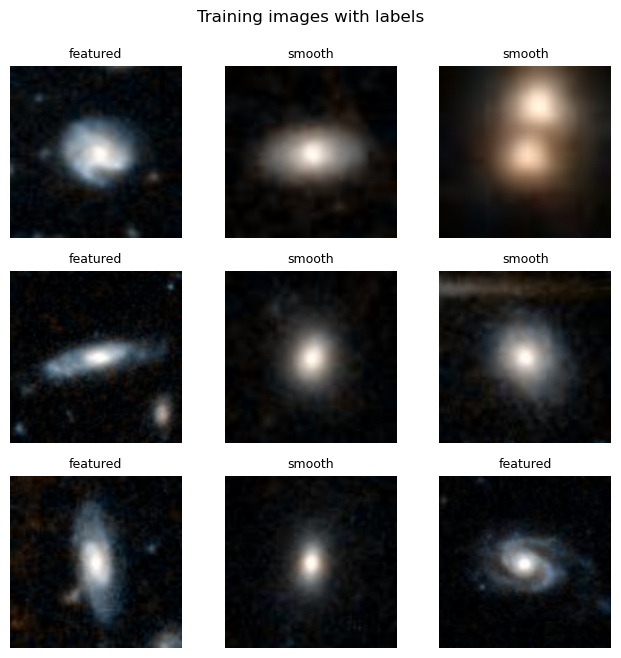

In [3]:
import torch, numpy as np, matplotlib.pyplot as plt


g = globals()

train_loader = g.get('train_loader_plot') or g.get('train_dataloader') or g.get('loader_train') or g.get('train_dl')
train_dataset = g.get('train_dataset_plot') or g.get('train_ds') or (train_loader.dataset if train_loader is not None and hasattr(train_loader, 'dataset') else None)
assert train_dataset is not None, "Could not locate a training dataset/loader. Please run the data prep cell first."

def label_name(y):
    if hasattr(train_dataset, 'classes'):
        try: return str(train_dataset.classes[int(y)])
        except: return str(y)
    if hasattr(train_dataset, 'class_to_idx'):
        rev = {v:k for k,v in train_dataset.class_to_idx.items()}
        return str(rev.get(int(y), y))
    return str(int(y))

if train_loader is not None:
    images, labels = next(iter(train_loader))
else:
    idx = torch.randperm(len(train_dataset))[:64]
    samples = [train_dataset[i] for i in idx]
    images = torch.stack([s[0] if torch.is_tensor(s[0]) else torchvision.transforms.functional.to_tensor(s[0]) for s in samples])
    labels = torch.tensor([int(s[1]) for s in samples])

B = min(images.shape[0], 64)
R = C = int(np.ceil(np.sqrt(B)))
fig, axes = plt.subplots(R, C, figsize=(2.2*C, 2.2*R))
axes = np.array(axes).reshape(R, C)

def to_display(img):
    x = img.detach().cpu().float()
    if x.ndim == 3 and x.shape[0] in (1,3):
        if x.min() < -0.1 or x.max() > 1.1:
            x = x * 0.5 + 0.5
        x = x.clamp(0,1)
        if x.shape[0] == 1: return x.squeeze(0).numpy(), 'gray'
        else: return np.transpose(x.numpy(), (1,2,0)), None
    return x.numpy(), 'gray'

for i in range(R*C):
    ax = axes[i//C, i% C]
    ax.axis('off')
    if i >= B: continue
    img, cmap = to_display(images[i])
    ax.imshow(img, cmap=cmap)
    ax.set_title(label_name(labels[i]), fontsize=9)

plt.suptitle("Training images with labels", y=0.99)
plt.tight_layout(); plt.show()

## Defining data augmentations

This will use the transformations defined in https://albumentations.ai/docs/ to augment the datasets

In [4]:
import albumentations as A
import cv2
import numpy as np

data_augmentation_pipeline = A.Compose([
    A.Rotate(
        limit=180,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        value=(0, 0, 0),         # fill color if you rotate out of frame (RGB)
        always_apply=True
    ),
    A.RandomResizedCrop(
        size=(224, 224),         # v2: use size=(H, W)
        scale=(0.7, 0.8),
        ratio=(0.9, 1.1),
        interpolation=cv2.INTER_LINEAR,
        always_apply=True
    ),
    A.VerticalFlip(p=0.5),
    A.ToFloat(max_value=255.0, always_apply=True),
])

def augment_func(samples):
    samples["pixel_values"] = [
        data_augmentation_pipeline(image=np.array(img.convert("RGB")))["image"]
        for img in samples["image"]
    ]
    return samples

train_set.set_transform(augment_func)
globals()["train_dataset"] = train_set


/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_88175/3296971643.py:6: UserWarning: Argument(s) 'value, always_apply' are not valid for transform Rotate
  A.Rotate(
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_88175/3296971643.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomResizedCrop
  A.RandomResizedCrop(
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_88175/3296971643.py:21: UserWarning: Argument(s) 'always_apply' are not valid for transform ToFloat
  A.ToFloat(max_value=255.0, always_apply=True),


However we don't want these augmentations to be applied to the test images. We only want to standardize them.

In [5]:

standardization_pipeline = A.Compose([
    A.Resize(height=224, width=224, interpolation=1), 
    A.ToFloat(max_value=255.0, always_apply=True),
])

def standardize_func(samples):
    samples["pixel_values"] = [
        standardization_pipeline(image=np.array(image))["image"] for image in samples["image"]
    ]
    return samples

test_set.set_transform(standardize_func)

/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_88175/2571306777.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform ToFloat
  A.ToFloat(max_value=255.0, always_apply=True),


## 🧠 Train a tiny ViT **from scratch** (analogous to the CNN)

This defines a small ViT and trains it using the same data loaders. It uses sinusoidal 2D positional
embeddings so it works with arbitrary image sizes (no fixed 224×224 assumption).

In [7]:
import math, time, torch, torch.nn as nn, torch.nn.functional as F
import torchvision

device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()  # for completeness (Linux/Windows)
    else torch.device("cpu")
)
print("Using:", device)

g = globals()
train_loader = g.get('train_loader') or g.get('train_dataloader') or g.get('loader_train') or g.get('train_dl')
val_loader   = g.get('val_loader') or g.get('valid_loader') or g.get('loader_val') or g.get('loader_valid')
train_dataset = g.get('train_dataset') or (train_loader.dataset if train_loader is not None else None)

assert train_loader is not None, "Need a training DataLoader named train_loader (or similar)."


Using: mps


In [8]:

def infer_num_classes(ds):
    if hasattr(ds, 'classes'): return len(ds.classes)
    if hasattr(ds, 'class_to_idx'): return len(ds.class_to_idx)
    X,Y = next(iter(train_loader))
    return int(max(Y).item()) + 1

num_classes = g.get('num_classes') or (infer_num_classes(train_dataset) if train_dataset is not None else infer_num_classes(None))

In [12]:
class PatchEmbed(nn.Module):
    def __init__(self, in_ch=3, embed_dim=192, patch=8):
        super().__init__()
        self.patch = patch
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch, stride=patch)
    def forward(self, x):
        x = self.proj(x)
        B, D, H, W = x.shape
        x = x.flatten(2).transpose(1,2)
        return x, (H, W)

def sinusoidal_2d(h, w, dim):
    y, x = torch.meshgrid(torch.arange(h), torch.arange(w), indexing='ij')
    y = y.flatten().float(); x = x.flatten().float()
    assert dim % 4 == 0, "dim must be multiple of 4"
    dim_half = dim // 4
    wy = 1.0 / (10000 ** (torch.arange(dim_half).float() / dim_half))
    wx = 1.0 / (10000 ** (torch.arange(dim_half).float() / dim_half))
    out = []
    for i in range(dim_half):
        out += [torch.sin(y * wy[i]), torch.cos(y * wy[i])]
    for i in range(dim_half):
        out += [torch.sin(x * wx[i]), torch.cos(x * wx[i])]
    pe = torch.stack(out, dim=1)
    return pe

class MLP(nn.Module):
    def __init__(self, dim, hidden_mult=4, drop=0.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim*hidden_mult)
        self.fc2 = nn.Linear(dim*hidden_mult, dim)
        self.act = nn.GELU()
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        x = self.fc1(x); x = self.act(x); x = self.drop(x)
        x = self.fc2(x); x = self.drop(x); return x

class Block(nn.Module):
    def __init__(self, dim, heads=3, drop=0.0, mlp_mult=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads=heads, batch_first=True, dropout=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_mult, drop)
    def forward(self, x):
        h = x; x = self.norm1(x)
        x, _ = self.attn(x, x, x, need_weights=False); x = x + h
        h = x; x = self.norm2(x)
        x = self.mlp(x); x = x + h
        return x

class TinyViT(nn.Module):
    def __init__(self, in_ch=3, num_classes=10, embed_dim=128, depth=6, heads=4, patch=8, drop=0.0):
        super().__init__()
        self.embed = PatchEmbed(in_ch, embed_dim, patch)
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([Block(embed_dim, heads, drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
    def forward(self, x):
        B, C, H, W = x.shape
        x, (h, w) = self.embed(x)
        pe = sinusoidal_2d(h, w, x.shape[-1]).to(x.device)
        pe = pe.unsqueeze(0).expand(B, -1, -1)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        pe_cls = torch.zeros(B, 1, x.shape[-1], device=x.device)
        x = x + torch.cat([pe_cls, pe], dim=1)
        x = self.pos_drop(x)
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)[:,0]
        return self.head(x)


In [14]:
try:
    sample_x, _ = next(iter(train_loader))
    in_ch = sample_x.shape[1]
except:
    in_ch = 3


epochs_vit  = g.get('epochs') or 2
lr_vit      = 3e-4
vit_model = TinyViT(in_ch=in_ch, num_classes=num_classes, embed_dim=128, depth=6, heads=4, patch=8, drop=0.0).to(device)
opt = torch.optim.AdamW(vit_model.parameters(), lr=lr_vit, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader):
    model.train(); total=correct=0; loss_sum=0.0
    for X,y in loader:
        X,y = X.to(device), y.to(device)
        logits = model(X); loss = criterion(logits,y)
        opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item()*X.size(0)
        pred = logits.argmax(1); total += y.size(0); correct += (pred==y).sum().item()
    return loss_sum/total, correct/total

@torch.no_grad()
def eval_accuracy(model, loader):
    model.eval(); total=correct=0; loss_sum=0.0
    for X,y in loader:
        X,y = X.to(device), y.to(device)
        logits = model(X); loss = criterion(logits,y)
        loss_sum += loss.item()*X.size(0)
        pred = logits.argmax(1); total += y.size(0); correct += (pred==y).sum().item()
    return loss_sum/total, correct/total


In [15]:
torch.save(vit_model.state_dict(), 'vit.pth')

In [16]:

print(f"Training TinyViT from scratch for {epochs_vit} epochs on device: {device}")
vit_history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
for ep in range(1, epochs_vit+1):
    tr_loss, tr_acc = train_one_epoch(vit_model, train_loader)
    if val_loader is not None:
        va_loss, va_acc = eval_accuracy(vit_model, val_loader)
    else:
        va_loss, va_acc = float('nan'), float('nan')
    vit_history["train_loss"].append(tr_loss); vit_history["train_acc"].append(tr_acc)
    vit_history["val_loss"].append(va_loss);   vit_history["val_acc"].append(va_acc)
    print(f"[ViT][{ep:03d}/{epochs_vit}] train loss={tr_loss:.4f} acc={tr_acc:.4f} | val loss={va_loss:.4f} acc={va_acc:.4f}")

Training TinyViT from scratch for 2 epochs on device: mps
[ViT][001/2] train loss=0.8435 acc=0.4931 | val loss=nan acc=nan
[ViT][002/2] train loss=0.8180 acc=0.5257 | val loss=nan acc=nan


## 📊 Compare CNN vs ViT results

This cell looks for a CNN model defined earlier (e.g., `cnn_model` or `model`) and compares its validation accuracy to the newly trained `vit_model`.

In [17]:
import torch

device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()  # for completeness (Linux/Windows)
    else torch.device("cpu")
)
print("Using:", device)



vit_model = TinyViT(in_ch=in_ch, num_classes=num_classes, embed_dim=128, depth=6, heads=4, patch=8, drop=0.0).to(device)
vit_model.load_state_dict(torch.load('vit.pth'))


assert vit_model is not None, "No vit_model found. Please run the ViT cell first."

val_loader = globals().get('val_loader') or globals().get('valid_loader') or globals().get('loader_val') or globals().get('loader_valid') or globals().get('train_loader')
assert val_loader is not None, "Need a validation (or training) DataLoader to compare."

@torch.no_grad()
def accuracy(model, loader):
    criterion = torch.nn.CrossEntropyLoss()
    model.eval(); total=correct=0; loss_sum=0.0
    for X,y in loader:
        X,y = X.to(device), y.to(device)
        logits = model(X); loss = criterion(logits,y)
        loss_sum += loss.item()*X.size(0)
        pred = logits.argmax(1); total += y.size(0); correct += (pred==y).sum().item()
    return loss_sum/total, correct/total

vit_val_loss, vit_val_acc = accuracy(vit_model, val_loader)

print("Validation comparison:")
print(f"  ViT: loss={vit_val_loss:.4f}, acc={vit_val_acc:.4f}")

Using: mps


/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_88175/786765945.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit_model.load_state_dict(torch.load('vit.pth

Validation comparison:
  ViT: loss=0.9570, acc=0.5069


In [32]:
# # --- Confusion matrices for ViT ---

# import numpy as np
# import matplotlib.pyplot as plt

# @torch.no_grad()
# def get_predictions(model, loader, device):
#     model.eval()
#     all_true, all_pred = [], []
#     images_list = []
#     for X, y in loader:
#         X = X.to(device)
#         logits = model(X)
#         pred = logits.argmax(1).cpu()
#         images_list.append(X.cpu().detach().numpy())
#         all_true.append(y.cpu())
#         all_pred.append(pred)
#     y_true = torch.cat(all_true).numpy()
#     y_pred = torch.cat(all_pred).numpy()
#     return y_true, y_pred, images

# y_true_vit, y_pred_vit, images = get_predictions(vit_model, val_loader, device)

correct = 0
total = 0
y_true = np.array([])
y_pred = np.array([])
images_list = []
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        images = images.to(device)
        labels = labels.to(device)
        outputs = vit_model(images)
        images_list.append(images.cpu())
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_true = np.concatenate([y_true, np.array(labels.cpu())])
        y_pred = np.concatenate([y_pred, np.array(predicted.cpu())])

print(f'Accuracy of the network on the test images: {100 * correct // total} %')

/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_88175/1738965355.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.concatenate([y_true, np.array(labels.cpu())])
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_88175/1738965355.py:43: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_pred = np.concatenate([y_pred, np.array(predicted.cpu())])


Accuracy of the network on the test images: 50 %


In [33]:
images_array = np.concatenate(images_list, axis=0)

Text(0.5, 0.95, 'Good predictions')

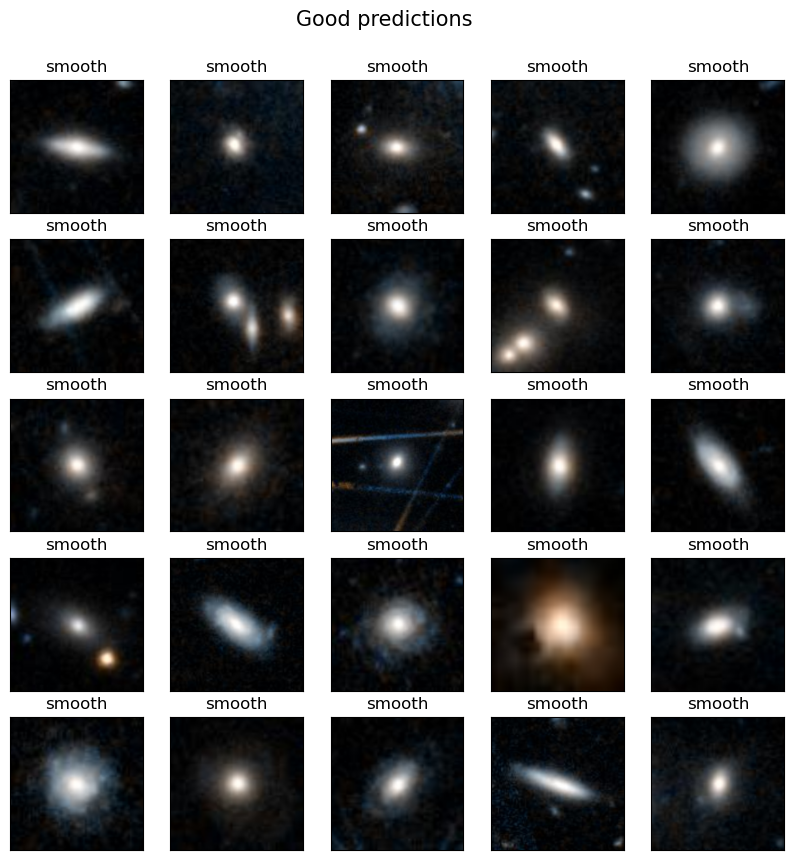

In [34]:
good_preds_ids = np.where(y_pred == y_true)[0]
rdm_25 = np.random.permutation(good_preds_ids)[:25]
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
ax = ax.flatten()
for i, id in enumerate(rdm_25):
    image = np.transpose(images_array[id], (1, 2, 0))
    ax[i].imshow(image)
    ax[i].set_title(label_name(y_pred[id]))
[axe.set_xticks([]) for axe in ax]
[axe.set_yticks([]) for axe in ax]
fig.suptitle('Good predictions', y=0.95, fontsize=15)

Text(0.5, 0.95, 'Bad predictions')

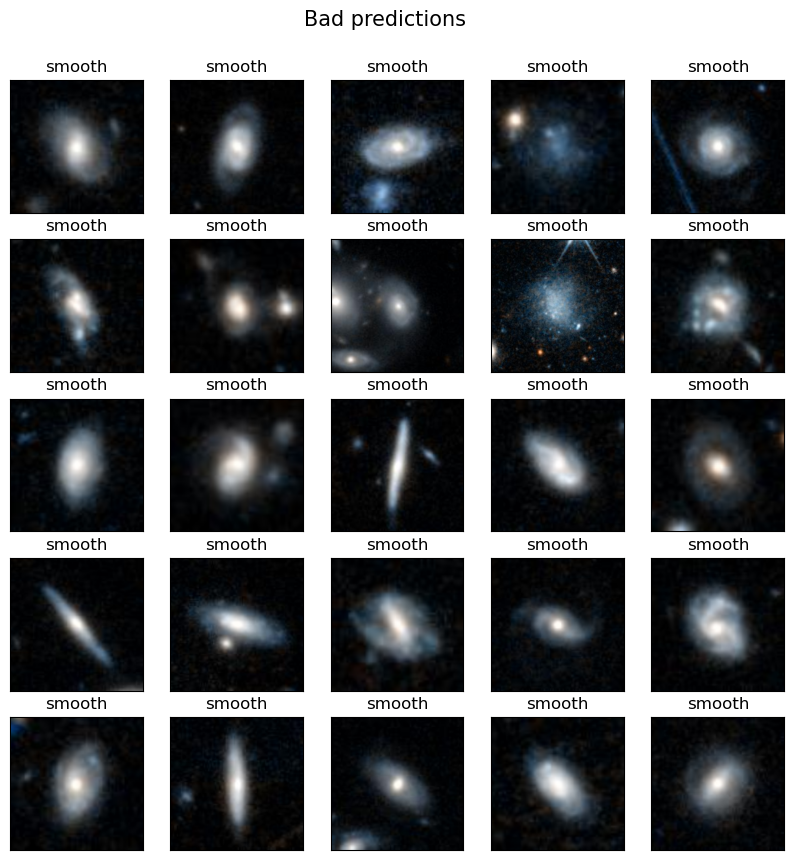

In [35]:
bad_preds_ids = np.where(y_pred != y_true)[0]
rdm_25 = np.random.permutation(bad_preds_ids)[:25]
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
ax = ax.flatten()
for i, id in enumerate(rdm_25):
    image = np.transpose(images_array[id], (1, 2, 0))
    ax[i].imshow(image)
    ax[i].set_title(label_name(y_pred[id]))
[axe.set_xticks([]) for axe in ax]
[axe.set_yticks([]) for axe in ax]
fig.suptitle('Bad predictions', y=0.95, fontsize=15)

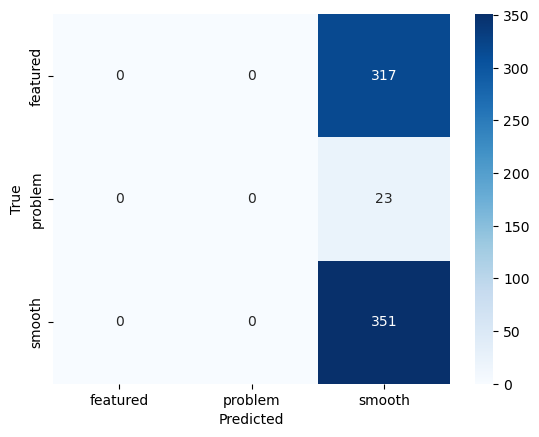

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[label_name(0), label_name(1), label_name(2)],
    yticklabels=[label_name(0), label_name(1), label_name(2)],
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Exercices

You job, if you accept it, is to improve the accuracy of the model.

To do so, here are some ideas:
- try new data augmentations from the Albumentations package (https://albumentations.ai/docs/)
- explore new CNN or ViTarchitectures found on the web (GitHub, Kaggle, arXiv..)
- look at the effect of the learning rate, epochs and batch_size on the training loss